In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors



plays = pd.read_csv('fbs_fbs_wildcats.csv')

C:\Users\bchm5\AppData\Local\Temp\ipykernel_21608\3291686373.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('fbs_fbs_wildcats.csv')


In [12]:
# plays['wildcat_position'].unique()

plays.loc[:, 'first_down_gained_numeric'] = \
    plays['first_down_gained'].fillna(0)

# set wildcats
wildcats = plays[plays['wildcat_play'] == 1]

# set te
te_wildcats = wildcats[wildcats['wildcat_position'] == 'TE']

# short runs
short_3_4_run_wildcats = wildcats[(wildcats['play_type'] == 'designed run') & (wildcats['distance'] <= 3) & (wildcats['down'].isin([3, 4]))]

# passes
pass_wildcats = wildcats[wildcats['play_type'] == 'dropback']

wildcat_position = wildcats.groupby(['wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    most_common_play=('play_type', lambda x: x.mode()[0])
).reset_index().sort_values('plays', ascending=False)

short_run_wildcats_position = short_3_4_run_wildcats.groupby(['wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    # most_common_play=('play_type', lambda x: x.mode()[0])
).reset_index().sort_values('plays', ascending=False)

print("Overall:", short_3_4_run_wildcats['first_down_gained_numeric'].mean())
short_run_wildcats_position
wildcats

Overall: 0.649402390438247


,season,week,pff_game_id,pff_play_id,sort_order,quarter,time_left_in_game,time_left_in_half,offense,defense,...,qb_scramble,yards_after_catch,pressure,sack,missed_tackle,yards_after_contact,wildcat_play,wildcat_player_id,wildcat_position,first_down_gained_numeric
440,2025,14,29564,6902540,60,2,2097,297,UTBY,FLCE,...,0,NaN,0,0,0,0.0,1,175035.0,HB,1.0
472,2025,14,29564,6904852,92,3,1448,1448,UTBY,FLCE,...,0,NaN,0,0,0,3.0,1,175035.0,HB,1.0
490,2025,14,29564,6905910,110,3,1108,1108,FLCE,UTBY,...,0,3.0,0,0,0,0.0,1,199393.0,HB,1.0
931,2025,14,29571,6914083,152,4,181,181,FLUN,FLST,...,0,NaN,0,0,0,6.0,1,184417.0,HB,1.0
932,2025,14,29571,6914105,153,4,135,135,FLUN,FLST,...,0,NaN,0,0,1,12.0,1,184417.0,HB,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137370,2025,12,29485,6817469,17,1,3209,1409,KYWE,TNMI,...,0,NaN,0,0,0,0.0,1,146736.0,HB,1.0
137412,2025,12,29485,6822395,59,2,2345,545,KYWE,TNMI,...,0,NaN,0,0,0,0.0,1,146736.0,HB,0.0
137484,2025,12,29485,6826388,131,3,1139,1139,KYWE,TNMI,...,0,NaN,0,0,0,2.0,1,199564.0,HB,0.0
138070,2025,07,29191,6599946,114,3,1057,1057,MSUN,WAST,...,0,NaN,0,0,0,5.0,1,190221.0,HB,1.0


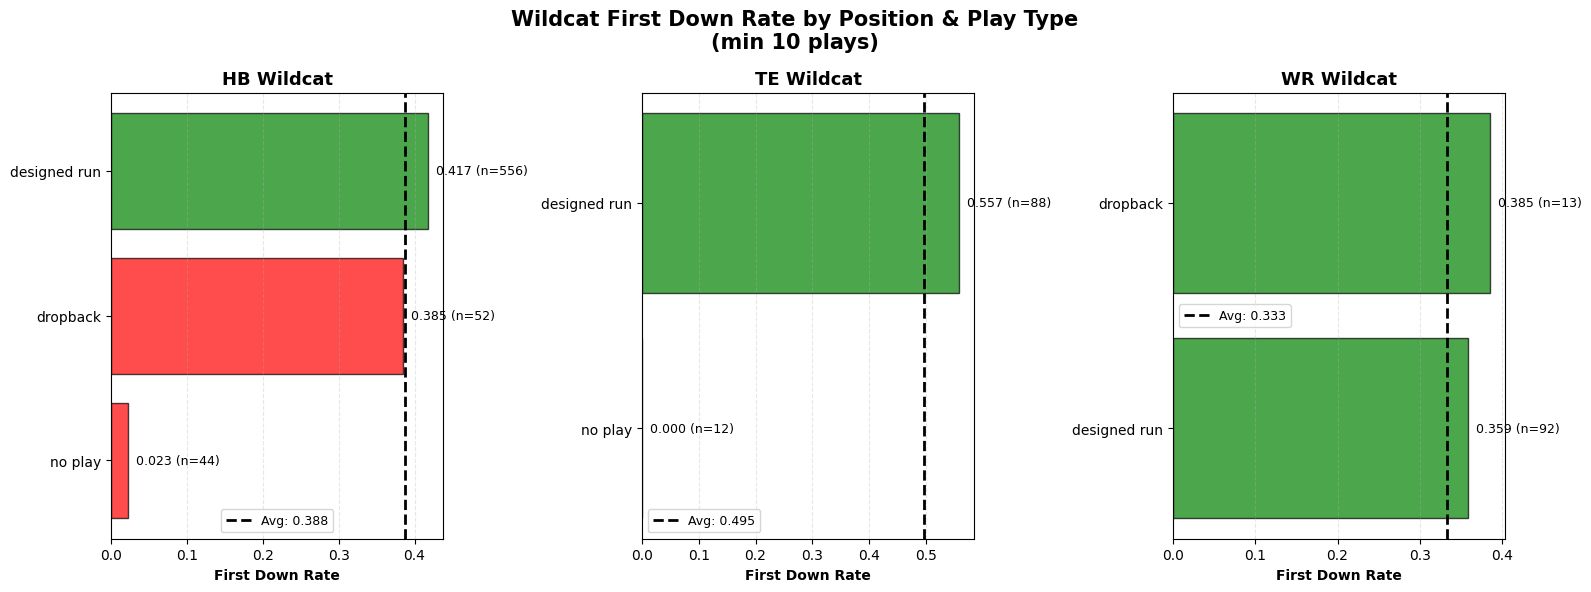

In [11]:
min_plays = 10  # adjust threshold as needed

filtered = wildcats[wildcats['wildcat_position'].isin(['HB', 'WR', 'TE'])]

plot_data = filtered.groupby(['wildcat_position', 'play_type']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean')
).reset_index()

plot_data = plot_data[plot_data['plays'] >= min_plays]

positions = plot_data['wildcat_position'].unique()
fig, axes = plt.subplots(1, len(positions), figsize=(16, 6), sharey=False)

for ax, position in zip(axes, positions):
    pos_data = plot_data[plot_data['wildcat_position'] == position].sort_values('first_down_rate', ascending=True)
    
    overall_avg = filtered[filtered['wildcat_position'] == position]['first_down_gained_numeric'].mean()
    
    colors = ['green' if r > overall_avg else 'red' for r in pos_data['first_down_rate']]
    
    bars = ax.barh(pos_data['play_type'], pos_data['first_down_rate'], color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, pos_data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, label=f'Avg: {overall_avg:.3f}')
    ax.set_title(f'{position} Wildcat', fontweight='bold', fontsize=13)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(f'Wildcat First Down Rate by Position & Play Type\n(min {min_plays} plays)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def assign_distance(d):
    if d < 4: return 'Short (< 4 yds)'
    elif d <= 8: return 'Medium (4-8 yds)'
    else: return 'Long (9+ yds)'

down_order = {1: 'Down 1', 2: 'Down 2', 3: 'Down 3', 4: 'Down 4'}

wildcats = plays[plays['wildcat_play'] == 1].copy()
wildcats['down_label'] = wildcats['down'].map(down_order)

wildcats['distance_bucket'] = wildcats['distance'].apply(assign_distance)

wildcat_distances = wildcats[wildcats['wildcat_position'].isin(['HB', 'WR', 'TE'])].groupby(['down_label', 'distance_bucket', 'play_type', 'wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean')
).reset_index()

# wildcat_distances


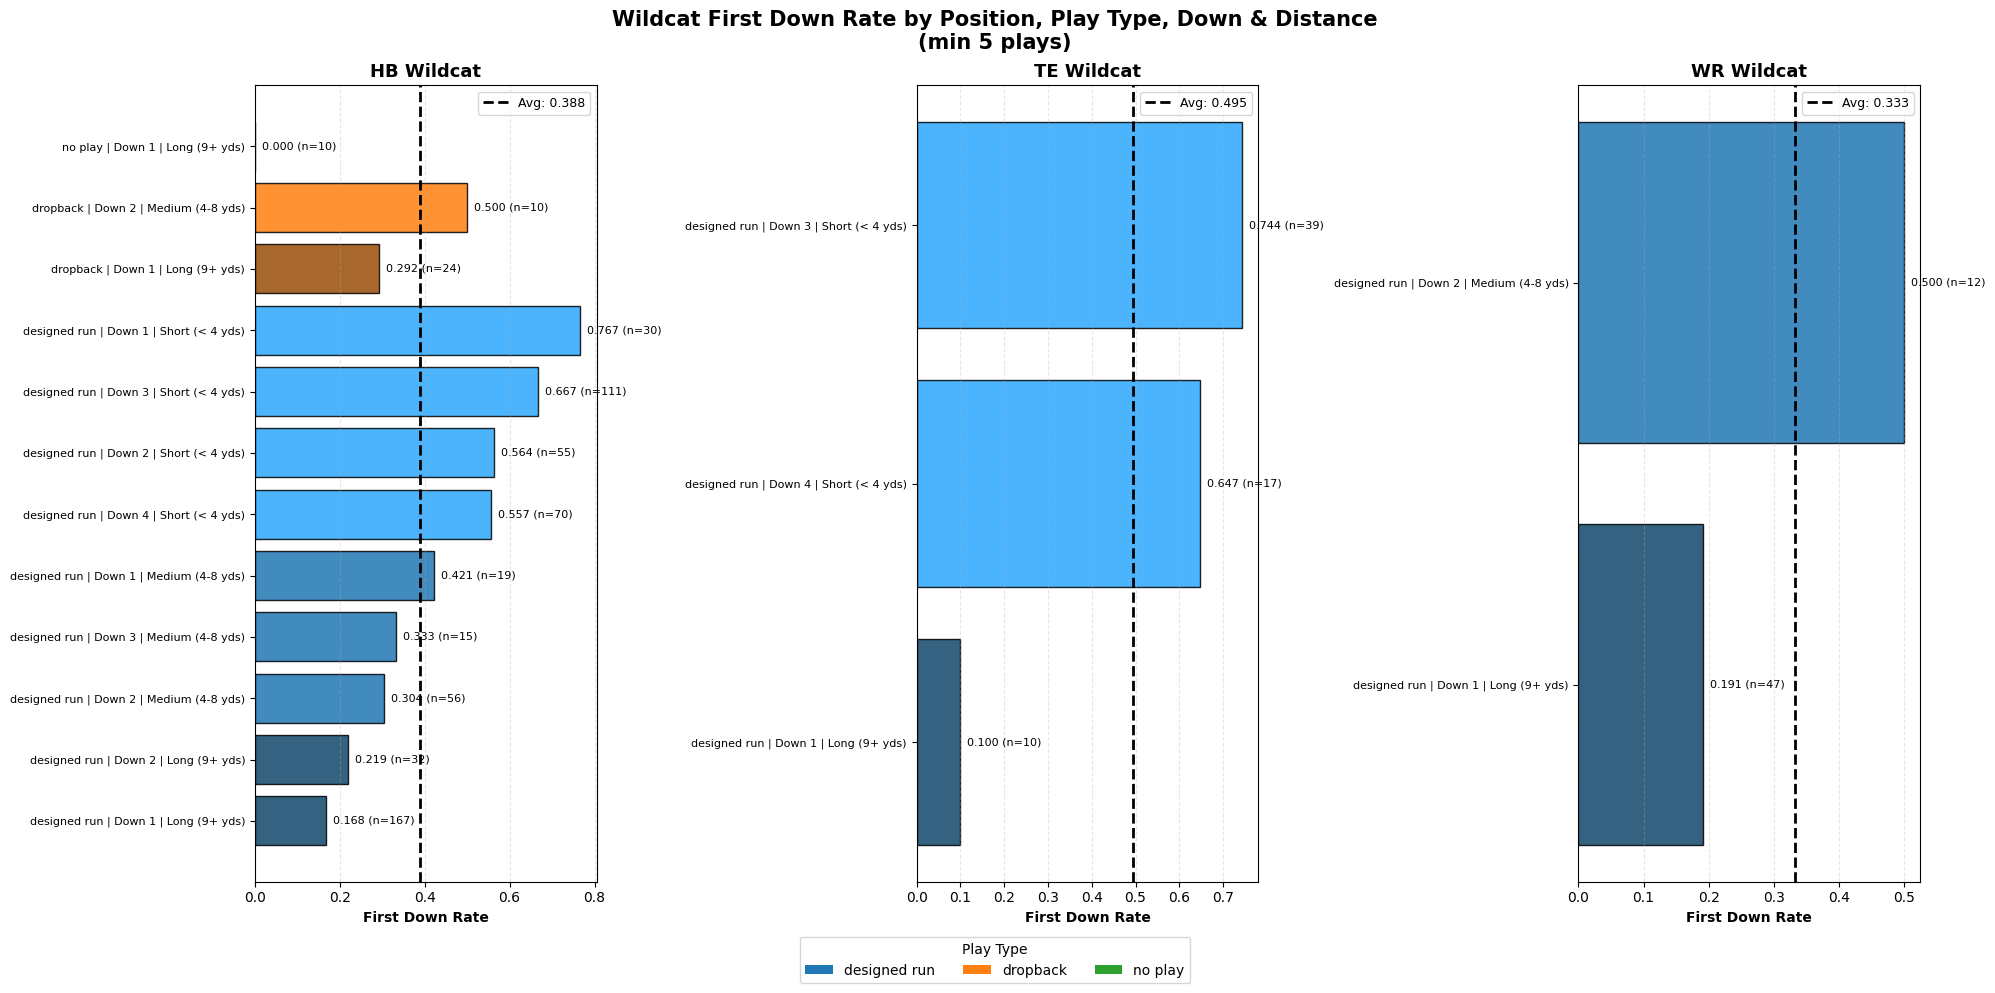

In [ ]:
distance_shade_factor = {
    'Short (< 4 yds)': 1.4,    # lighter
    'Medium (4-8 yds)': 1.0,   # base color
    'Long (9+ yds)': 0.6        # darker
}

def adjust_color(color, factor):
    rgb = mcolors.to_rgb(color)
    adjusted = tuple(min(1.0, max(0.0, c * factor)) for c in rgb)
    return adjusted


min_plays = 10

filtered = wildcats[wildcats['wildcat_position'].isin(['HB', 'WR', 'TE'])]
wildcat_distances = wildcat_distances[wildcat_distances['plays'] >= min_plays].copy()
wildcat_distances['y_label'] = wildcat_distances['play_type'] + ' | ' + wildcat_distances['down_label'] + ' | ' + wildcat_distances['distance_bucket']

# assign a color per play type
play_types = wildcat_distances['play_type'].unique()
color_palette = plt.cm.tab10.colors
play_type_colors = {pt: color_palette[i % len(color_palette)] for i, pt in enumerate(play_types)}

positions = wildcat_distances['wildcat_position'].unique()
fig, axes = plt.subplots(1, len(positions), figsize=(20, 10), sharey=False)

for ax, position in zip(axes, positions):
    pos_data = wildcat_distances[wildcat_distances['wildcat_position'] == position]\
        .sort_values(['play_type', 'first_down_rate'], ascending=[True, True])\
        .reset_index(drop=True)
    
    overall_avg = filtered[filtered['wildcat_position'] == position]['first_down_gained_numeric'].mean()
    
    for pos, (_, row) in enumerate(pos_data.iterrows()):
        base_color = play_type_colors[row['play_type']]
        factor = distance_shade_factor[row['distance_bucket']]
        color = adjust_color(base_color, factor)
        ax.barh(pos, row['first_down_rate'], color=color, alpha=0.85, edgecolor='black')
        ax.text(row['first_down_rate'], pos,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=8)
    
    ax.set_yticks(range(len(pos_data)))
    ax.set_yticklabels(pos_data['y_label'], fontsize=8)
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, label=f'Avg: {overall_avg:.3f}')
    ax.set_title(f'{position} Wildcat', fontweight='bold', fontsize=13)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

# shared play type legend
legend_elements = [Patch(facecolor=c, label=pt) for pt, c in play_type_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=len(play_types),
           fontsize=10, title='Play Type', bbox_to_anchor=(0.5, 0))

plt.suptitle(f'Wildcat First Down Rate by Position, Play Type, Down & Distance\n(min {min_plays} plays)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

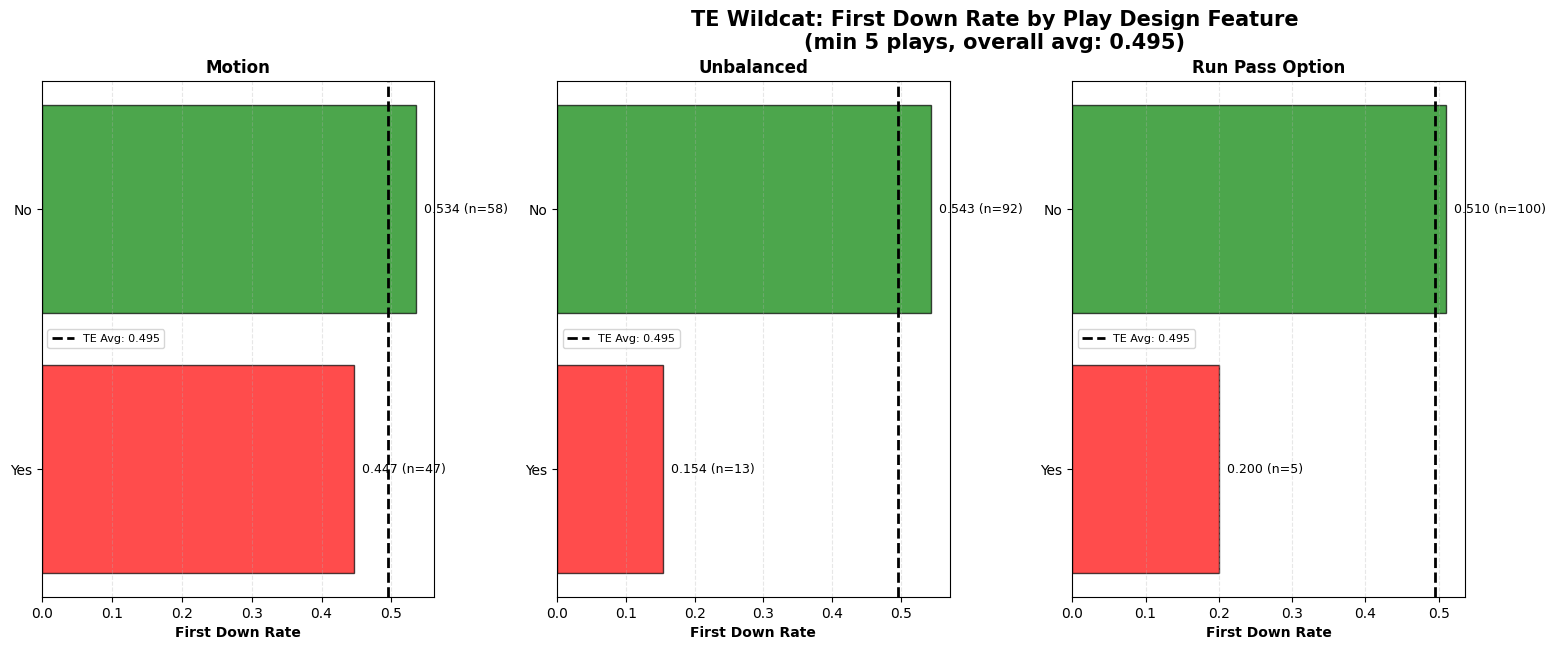

In [24]:
min_plays = 5  # lower threshold given smaller sample

overall_avg = te_wildcats['first_down_gained_numeric'].mean()

design_features = ['motion', 'unbalanced', 'run_pass_option']

plot_data = {}
for feature in design_features:
    grouped = te_wildcats.groupby(feature).agg(
        plays=('wildcat_play', 'size'),
        first_down_rate=('first_down_gained_numeric', 'mean')
    ).reset_index()
    grouped = grouped[grouped['plays'] >= min_plays]
    grouped['feature'] = feature
    grouped.rename(columns={feature: 'value'}, inplace=True)
    plot_data[feature] = grouped
    grouped['value'] = grouped['value'].map({0: 'No', 1: 'Yes'})

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, (feature, data) in enumerate(plot_data.items()):
    ax = axes[i]
    data = data.sort_values('first_down_rate', ascending=True)
    
    colors = ['green' if r > overall_avg else 'red' for r in data['first_down_rate']]
    bars = ax.barh(data['value'].astype(str), data['first_down_rate'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, 
               label=f'TE Avg: {overall_avg:.3f}')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

# hide unused subplots
for j in range(len(plot_data), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'TE Wildcat: First Down Rate by Play Design Feature\n(min {min_plays} plays, overall avg: {overall_avg:.3f})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

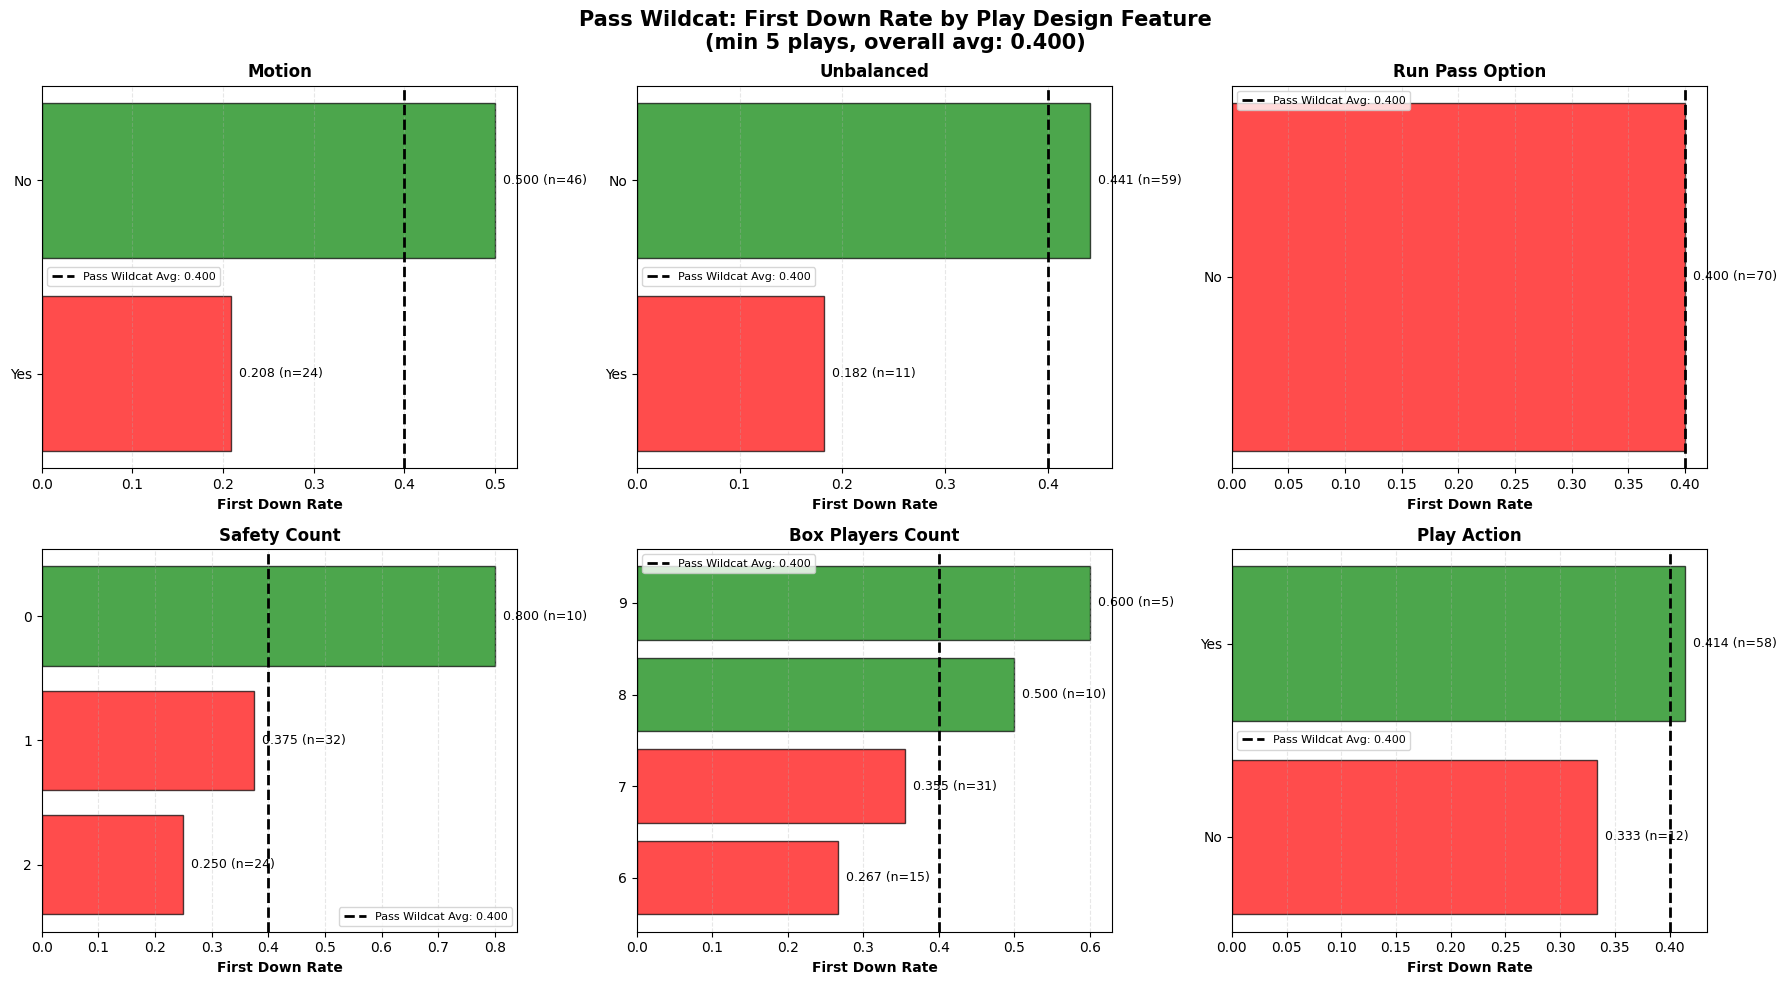

In [32]:
min_plays = 5

overall_avg = pass_wildcats['first_down_gained_numeric'].mean()

design_features = ['motion', 'unbalanced', 'run_pass_option', 'safety_count', 'box_players_count', 'play_action']

plot_data = {}
for feature in design_features:
    grouped = pass_wildcats.groupby(feature).agg(
        plays=('wildcat_play', 'size'),
        first_down_rate=('first_down_gained_numeric', 'mean')
    ).reset_index()
    grouped = grouped[grouped['plays'] >= min_plays]
    grouped['feature'] = feature
    grouped.rename(columns={feature: 'value'}, inplace=True)
    # only map binary features
    if feature in ['motion', 'unbalanced', 'run_pass_option', 'play_action']:
        grouped['value'] = grouped['value'].map({0: 'No', 1: 'Yes'})
    plot_data[feature] = grouped

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feature, data) in enumerate(plot_data.items()):
    ax = axes[i]
    data = data.sort_values('first_down_rate', ascending=True)
    
    colors = ['green' if r > overall_avg else 'red' for r in data['first_down_rate']]
    bars = ax.barh(data['value'].astype(str), data['first_down_rate'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, 
               label=f'Pass Wildcat Avg: {overall_avg:.3f}')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

for j in range(len(plot_data), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Pass Wildcat: First Down Rate by Play Design Feature\n(min {min_plays} plays, overall avg: {overall_avg:.3f})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()